In [55]:
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt


# Funciones para leer rasters

Las siguientes funciones se han usado en el *Inciso 2*.

In [3]:
# Función que permite buscar el archivo raster.
def buscar_raster(lago, fecha, banda):
    carpeta = RAIZ / lago
    nombre_esperado = f"{lago}_{fecha}_{banda}".lower()

    archivos = [archivo for archivo in carpeta.iterdir() if archivo.is_file() and archivo.suffix.lower() in {".tif", ".tiff"}
                and archivo.stem.lower() == nombre_esperado]

    return archivos[0]

In [4]:
# Función que permite leer el raster.
def leer_raster_referencia(ruta):
    with rasterio.open(ruta) as src:
        arreglo = (src.read(1, masked=True).astype("float32").filled(np.nan))

        informacion = {
            "height": src.height,
            "width": src.width,
            "transform": src.transform,
            "crs": src.crs
        }

    return arreglo, informacion

In [5]:
# Función que verifica que los rasters sean compatibles.
def leer_y_alinear(ruta, referencia):
    with rasterio.open(ruta) as src:
        origen = src.read(1, masked=True).astype("float32").filled(np.nan)

        misma_grilla = (src.height == referencia["height"] and src.width == referencia["width"]
                        and src.transform.almost_equals(referencia["transform"]) and src.crs == referencia["crs"])

        if misma_grilla:
            return origen

        destino = np.full((referencia["height"], referencia["width"]), np.nan, dtype="float32")

        reproject(source=origen,
            destination=destino,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=referencia["transform"],
            dst_crs=referencia["crs"],
            src_nodata=np.nan,
            dst_nodata=np.nan,
            resampling=Resampling.bilinear
        )

        return destino

In [6]:
# Función que normaliza la reflectancia.
def convertir_reflectancia(arreglo):
    return arreglo / 10000

# Calcula un índice normalizado evitando divisiones entre cero.
def calcular_indice_normalizado(banda_1, banda_2):
    denominador = banda_1 + banda_2
    return np.divide(banda_1 - banda_2, denominador, out=np.full_like(banda_1, np.nan),
                     where=np.abs(denominador) > 1e-10)

In [21]:
#FUNCIÓN PARA REPROYECTAR A EPSG_36216 PARA EL INCISO 6.1.
from rasterio.warp import (
    calculate_default_transform,
    reproject,
    Resampling
)

CRS_DESTINO = "EPSG:32615"


def leer_y_reproyectar(ruta, crs_destino=CRS_DESTINO):

    with rasterio.open(ruta) as src:

        transform, width, height = calculate_default_transform(
            src.crs,
            crs_destino,
            src.width,
            src.height,
            *src.bounds
        )

        destino = np.full(
            (height, width),
            np.nan,
            dtype=np.float32
        )

        reproject(
            source=rasterio.band(src, 1),
            destination=destino,

            src_transform=src.transform,
            src_crs=src.crs,

            dst_transform=transform,
            dst_crs=crs_destino,

            src_nodata=src.nodata,
            dst_nodata=np.nan,

            resampling=Resampling.bilinear
        )

        referencia = {
            "crs": rasterio.crs.CRS.from_string(
                crs_destino
            ),
            "transform": transform,
            "width": width,
            "height": height
        }

    return destino, referencia

In [24]:
#Esta función reproyecta todas las bandas a la misma cuadrícula de la de referencia
def leer_y_alinear_utm(ruta, referencia):

    with rasterio.open(ruta) as src:

        destino = np.full(
            (
                referencia["height"],
                referencia["width"]
            ),
            np.nan,
            dtype=np.float32
        )

        reproject(
            source=rasterio.band(src, 1),
            destination=destino,

            src_transform=src.transform,
            src_crs=src.crs,

            dst_transform=referencia["transform"],
            dst_crs=referencia["crs"],

            src_nodata=src.nodata,
            dst_nodata=np.nan,

            resampling=Resampling.bilinear
        )

    return destino

# 6.1. División de los lagos en una cuadrícula regular de 1km $\times$ 1km

In [25]:
b03, referencia = leer_y_reproyectar(ruta_b03)#se reproyecta usando B03 como banda de referencia

b04 = leer_y_alinear_utm(ruta_b04,referencia)

b05 = leer_y_alinear_utm(ruta_b05,referencia)

b08 = leer_y_alinear_utm(ruta_b08,referencia)

In [26]:
#Se procede a verificar para EPSG
assert referencia["crs"].to_epsg() == 32615, (
    f"CRS incorrecto: {referencia['crs']}"
)

In [27]:
TAMANO_BLOQUE = 1000

In [17]:
#Código del inciso 20
# Dirección
RAIZ = Path("datos_lagos")

# Fechas
FECHAS = {
    'amatitlan': ["2025-01-28", "2025-04-15", "2025-04-28", "2025-11-24", "2026-01-08", "2026-02-02",
                "2026-02-07", "2026-03-29", "2026-04-13", "2026-04-28", "2026-06-19"],
    'atitlan': ["2025-01-18", "2025-04-13", "2025-05-13", "2025-07-17", "2025-11-21", "2025-12-29",
                "2026-02-12", "2026-03-24", "2026-04-13", "2026-04-28", "2026-07-22"]
        }

UMBRAL_CHLA = 12.0
TAMANO_CELDA_METROS = 1000  # Cada observación representa una celda de 1000 x 1000 m - porque la instrucción dicta que sea 1km x 1km
UMBRAL_NDWI_AGUA = 0.0     # Punto de partida; conviene validarlo con muestras locales
UMBRAL_NDVI_TIERRA = 0.20  # Separa vegetación/tierra de superficies con poca vegetación

In [31]:
resultados = []

for lago, fechas_lago in FECHAS.items():
    for fecha in fechas_lago:

        # Extracción de las bandas y preprocesamiento de las mismas.
        ruta_b03 = buscar_raster(lago, fecha, "B03")
        ruta_b04 = buscar_raster(lago, fecha, "B04")
        ruta_b05 = buscar_raster(lago, fecha, "B05")
        ruta_b08 = buscar_raster(lago, fecha, "B08")

        b03, referencia = leer_raster_referencia(ruta_b03)
        b04 = leer_y_alinear(ruta_b04, referencia)
        b05 = leer_y_alinear(ruta_b05, referencia)
        b08 = leer_y_alinear(ruta_b08, referencia)

        b03 = convertir_reflectancia(b03)
        b04 = convertir_reflectancia(b04)
        b05 = convertir_reflectancia(b05)
        b08 = convertir_reflectancia(b08)

        # Índices espectrales de Sentinel-2.
        ndci = calcular_indice_normalizado(b05, b04)  # (B05 - B04) / (B05 + B04)
        ndvi = calcular_indice_normalizado(b08, b04)  # (NIR - rojo) / (NIR + rojo)
        ndwi = calcular_indice_normalizado(b03, b08)  # (verde - NIR) / (verde + NIR)

        # Cálculo de clorofila-a en µg/L
        chl_a = (826.57 * ndci**3 - 176.43 * ndci**2  + 19.0 * ndci + 4.071)

        # Se truncan los valores.
        chl_a = np.clip(chl_a, 0, 500)

        
        mascara_valida = (np.isfinite(b03) & np.isfinite(b04) & np.isfinite(b05) & np.isfinite(b08) & np.isfinite(ndci)
                          & np.isfinite(ndvi) & np.isfinite(ndwi)
                          & np.isfinite(chl_a) & (b03 >= 0) & (b04 >= 0) & (b05 >= 0) & (b08 >= 0) & ((b03 + b04 + b05 + b08) > 0))
        filas, columnas = np.where(mascara_valida)

        # Transformación.
        transformacion = referencia["transform"]

        # Coordenadas.
        coordenada_x = (transformacion.c  + (columnas + 0.5) * transformacion.a + (filas + 0.5) * transformacion.b)
        coordenada_y = (transformacion.f + (columnas + 0.5) * transformacion.d + (filas + 0.5) * transformacion.e)

        # La agrupación de 10 x 10 se expresa en metros; por ello el CRS debe ser proyectado.
        if referencia["crs"] is None or not referencia["crs"].is_projected:
            raise ValueError(f"El raster {ruta_b03.name} debe tener un CRS proyectado en metros.")

        # Se asigna a cada píxel una celda regular de 1 km x 1 km
        tabla_pixeles = pd.DataFrame({"x_pixel": coordenada_x, "y_pixel": coordenada_y,
                                       "b03": b03[mascara_valida], "b04": b04[mascara_valida],
                                       "b05": b05[mascara_valida], "b08": b08[mascara_valida],
                                       "ndci": ndci[mascara_valida], "ndvi": ndvi[mascara_valida],
                                       "ndwi": ndwi[mascara_valida], "chl_a_estimada": chl_a[mascara_valida]})
        tabla_pixeles["es_agua"] = (tabla_pixeles["ndwi"] > UMBRAL_NDWI_AGUA).astype("int8")
        tabla_pixeles["es_tierra"] = ((tabla_pixeles["ndwi"] <= UMBRAL_NDWI_AGUA)
                                           & (tabla_pixeles["ndvi"] >= UMBRAL_NDVI_TIERRA)).astype("int8")
        tabla_pixeles["es_otro"] = ((tabla_pixeles["es_agua"] == 0)
                                         & (tabla_pixeles["es_tierra"] == 0)).astype("int8")
        tabla_pixeles["bloque_columna"] = np.floor(tabla_pixeles["x_pixel"]/ TAMANO_BLOQUE).astype("int64")
        tabla_pixeles["bloque_fila"] = np.floor(tabla_pixeles["y_pixel"]/ TAMANO_BLOQUE).astype("int64")
        #tabla_pixeles["celda_columna"] = np.floor(tabla_pixeles["x_pixel"] / TAMANO_CELDA_METROS).astype("int64")
        #tabla_pixeles["celda_fila"] = np.floor(tabla_pixeles["y_pixel"] / TAMANO_CELDA_METROS).astype("int64")

        # Una fila final por celda: medias espectrales y proporción de cada superficie.
        tabla_fecha = (tabla_pixeles.groupby(["bloque_fila", "bloque_columna"], as_index=False)
                       .agg(b03=("b03", "mean"), b04=("b04", "mean"), b05=("b05", "mean"),
                            b08=("b08", "mean"), ndci=("ndci", "mean"),
                            ndvi=("ndvi", "mean"), ndwi=("ndwi", "mean"),
                            proporcion_agua=("es_agua", "mean"), proporcion_tierra=("es_tierra", "mean"),
                            proporcion_otro=("es_otro", "mean"), chl_a_estimada=("chl_a_estimada", "mean"),
                            pixeles_validos=("chl_a_estimada", "size")))
        columnas_proporcion = ["proporcion_agua", "proporcion_tierra", "proporcion_otro"]
        tabla_fecha["lago"] = lago
        tabla_fecha["fecha"] = pd.to_datetime(fecha)
        #tabla_fecha["x"] = (tabla_fecha["celda_columna"] + 0.5) * TAMANO_CELDA_METROS
        #tabla_fecha["y"] = (tabla_fecha["celda_fila"] + 0.5) * TAMANO_CELDA_METROS
        tabla_fecha["x"]=(tabla_fecha["bloque_columna"]+0.5)* TAMANO_BLOQUE
        tabla_fecha["y"]=(tabla_fecha["bloque_fila"]+0.5)*TAMANO_BLOQUE
        tabla_fecha["alta_cianobacteria"] = (tabla_fecha["chl_a_estimada"] >= UMBRAL_CHLA).astype("int8")
        tabla_fecha = tabla_fecha[["lago", "fecha", "bloque_fila", "bloque_columna", "x", "y",
                                   "b03", "b04", "b05", "b08", "ndci", "ndvi", "ndwi",
                                   "proporcion_agua", "proporcion_tierra",
                                   "proporcion_otro", "chl_a_estimada",
                                   "pixeles_validos", "alta_cianobacteria"]]

        resultados.append(tabla_fecha)

df_respuesta = pd.concat(resultados, ignore_index=True)

In [32]:
df_respuesta.head()

,lago,fecha,bloque_fila,bloque_columna,x,y,b03,b04,b05,b08,ndci,ndvi,ndwi,proporcion_agua,proporcion_tierra,proporcion_otro,chl_a_estimada,pixeles_validos,alta_cianobacteria
0,amatitlan,2025-01-28,1594,754,754500.0,1594500.0,0.132696,0.138698,0.144296,0.184101,0.032449,0.145970,-0.164748,0.009569,0.251196,0.739234,4.664739,418,0
1,amatitlan,2025-01-28,1594,755,755500.0,1594500.0,0.088559,0.080894,0.100493,0.206473,0.147543,0.441826,-0.395174,0.003158,0.763158,0.233684,8.154140,950,0
2,amatitlan,2025-01-28,1594,756,756500.0,1594500.0,0.067304,0.051320,0.077896,0.217633,0.217581,0.613118,-0.518424,0.000000,0.994737,0.005263,10.173271,950,0
3,amatitlan,2025-01-28,1594,757,757500.0,1594500.0,0.068795,0.054360,0.082456,0.203877,0.214208,0.574106,-0.486190,0.000000,0.998947,0.001053,10.263282,950,0
4,amatitlan,2025-01-28,1594,758,758500.0,1594500.0,0.071946,0.065809,0.087581,0.176324,0.154864,0.431844,-0.389299,0.001053,0.831579,0.167368,8.614012,950,0


In [33]:
df_respuesta["id_bloque"] = (
    df_respuesta["lago"].astype(str)
    + "_"
    + df_respuesta["bloque_fila"].astype(str)
    + "_"
    + df_respuesta["bloque_columna"].astype(str)
)

In [34]:
bloques_por_lago = (
    df_respuesta
    .groupby("lago")["id_bloque"]
    .nunique()
    .reset_index(name="numero_bloques")
)

display(bloques_por_lago)

,lago,numero_bloques
0,amatitlan,150
1,atitlan,504


In [35]:
bloques_fecha = (
    df_respuesta
    .groupby(["lago", "fecha"])["id_bloque"]
    .nunique()
    .reset_index(name="bloques_validos")
)

display(bloques_fecha)

,lago,fecha,bloques_validos
0,amatitlan,2025-01-28,150
1,amatitlan,2025-04-15,150
2,amatitlan,2025-04-28,150
3,amatitlan,2025-11-24,150
4,amatitlan,2026-01-08,150
5,amatitlan,2026-02-02,150
6,amatitlan,2026-02-07,150
7,amatitlan,2026-03-29,150
8,amatitlan,2026-04-13,150
9,amatitlan,2026-04-28,150


In [36]:
observaciones_bloque = (
    df_respuesta
    .groupby(["lago", "id_bloque"])
    .size()
    .reset_index(
        name="observaciones"
    )
)

display(observaciones_bloque)

,lago,id_bloque,observaciones
0,amatitlan,amatitlan_1594_754,11
1,amatitlan,amatitlan_1594_755,11
2,amatitlan,amatitlan_1594_756,11
3,amatitlan,amatitlan_1594_757,11
4,amatitlan,amatitlan_1594_758,11
...,...,...,...
649,atitlan,atitlan_1631_703,11
650,atitlan,atitlan_1631_704,11
651,atitlan,atitlan_1631_705,11
652,atitlan,atitlan_1631_706,11


In [37]:
resumen_observaciones = (
    observaciones_bloque
    .groupby("lago")["observaciones"]
    .describe()
)

display(resumen_observaciones)

,count,mean,std,min,25%,50%,75%,max
lago,,,,,,,,
amatitlan,150.0,11.0,0.0,11.0,11.0,11.0,11.0,11.0
atitlan,504.0,11.0,0.0,11.0,11.0,11.0,11.0,11.0


In [39]:
pixeles_validos=("chl_a_estimada", "size")
pixeles_por_bloque = (
    df_respuesta
    .groupby("lago")["pixeles_validos"]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max"
    ])
)

display(pixeles_por_bloque)#estadísticas de pixeles válidos por bloque

,count,mean,median,min,max
lago,,,,,
amatitlan,1650,2083.852727,2500.0,171,2500
atitlan,5544,2398.560606,2500.0,1292,2500


In [40]:
resumen_espacial = (
    df_respuesta
    .groupby("lago")
    .agg(
        bloques_unicos=(
            "id_bloque",
            "nunique"
        ),

        observaciones_bloque_fecha=(
            "id_bloque",
            "size"
        ),

        pixeles_promedio=(
            "pixeles_validos",
            "mean"
        ),

        pixeles_mediana=(
            "pixeles_validos",
            "median"
        ),

        pixeles_minimo=(
            "pixeles_validos",
            "min"
        ),

        pixeles_maximo=(
            "pixeles_validos",
            "max"
        )
    )
    .reset_index()
)

display(resumen_espacial)

,lago,bloques_unicos,observaciones_bloque_fecha,pixeles_promedio,pixeles_mediana,pixeles_minimo,pixeles_maximo
0,amatitlan,150,1650,2083.852727,2500.0,171,2500
1,atitlan,504,5544,2398.560606,2500.0,1292,2500


# 6.2. Asignación de cada observación a cada uno de los bloques espaciales

In [48]:
df_respuesta.head() #esto ha sido realizado con anterioridad en el primer inciso.

,lago,fecha,bloque_fila,bloque_columna,x,y,b03,b04,b05,b08,ndci,ndvi,ndwi,proporcion_agua,proporcion_tierra,proporcion_otro,chl_a_estimada,pixeles_validos,alta_cianobacteria,id_bloque
0,amatitlan,2025-01-28,1594,754,754500.0,1594500.0,0.132696,0.138698,0.144296,0.184101,0.032449,0.145970,-0.164748,0.009569,0.251196,0.739234,4.664739,418,0,amatitlan_1594_754
1,amatitlan,2025-01-28,1594,755,755500.0,1594500.0,0.088559,0.080894,0.100493,0.206473,0.147543,0.441826,-0.395174,0.003158,0.763158,0.233684,8.154140,950,0,amatitlan_1594_755
2,amatitlan,2025-01-28,1594,756,756500.0,1594500.0,0.067304,0.051320,0.077896,0.217633,0.217581,0.613118,-0.518424,0.000000,0.994737,0.005263,10.173271,950,0,amatitlan_1594_756
3,amatitlan,2025-01-28,1594,757,757500.0,1594500.0,0.068795,0.054360,0.082456,0.203877,0.214208,0.574106,-0.486190,0.000000,0.998947,0.001053,10.263282,950,0,amatitlan_1594_757
4,amatitlan,2025-01-28,1594,758,758500.0,1594500.0,0.071946,0.065809,0.087581,0.176324,0.154864,0.431844,-0.389299,0.001053,0.831579,0.167368,8.614012,950,0,amatitlan_1594_758


In [70]:
def crear_geometria_bloques(df, tamano=1000):

    bloques = df[
        ["lago", "bloque_fila", "bloque_columna"]
    ].drop_duplicates().copy()

    def crear_bloque(row):

        xmin = row["bloque_columna"] * tamano
        ymin = row["bloque_fila"] * tamano

        xmax = xmin + tamano
        ymax = ymin + tamano

        return box(
            xmin,
            ymin,
            xmax,
            ymax
        )

    bloques["geometry"] = bloques.apply(
        crear_bloque,
        axis=1
    )

    return gpd.GeoDataFrame(
        bloques,
        geometry="geometry",
        crs="EPSG:32615"
    )

In [71]:
gdf_bloques = crear_geometria_bloques(df_respuesta,tamano=1000)
print(gdf_bloques.head())
print(gdf_bloques.crs)
print("Bloques:", len(gdf_bloques))

        lago  bloque_fila  bloque_columna  \
0  amatitlan         1594             754   
1  amatitlan         1594             755   
2  amatitlan         1594             756   
3  amatitlan         1594             757   
4  amatitlan         1594             758   

                                            geometry  
0  POLYGON ((755000 1594000, 755000 1595000, 7540...  
1  POLYGON ((756000 1594000, 756000 1595000, 7550...  
2  POLYGON ((757000 1594000, 757000 1595000, 7560...  
3  POLYGON ((758000 1594000, 758000 1595000, 7570...  
4  POLYGON ((759000 1594000, 759000 1595000, 7580...  
EPSG:32615
Bloques: 654


In [72]:
amatitlan = gpd.read_file("datos_lagos/amatitlan.geojson")

atitlan = gpd.read_file("datos_lagos/atitlan.geojson")

In [73]:
print(amatitlan.crs)
print(atitlan.crs)

EPSG:4326
EPSG:4326


In [74]:
#Se procede a proyectarlos al CRS
amatitlan_utm = amatitlan.to_crs("EPSG:32615")

atitlan_utm = atitlan.to_crs("EPSG:32615")


In [86]:
print("CRS GeoJSON:", amatitlan.crs)
print("CRS bloques:", gdf_bloques.crs)

CRS GeoJSON: EPSG:4326
CRS bloques: EPSG:32615


In [88]:
amatitlan_utm = amatitlan.to_crs("EPSG:32615")
print(amatitlan_utm.crs)
print(gdf_bloques.crs)

EPSG:32615
EPSG:32615


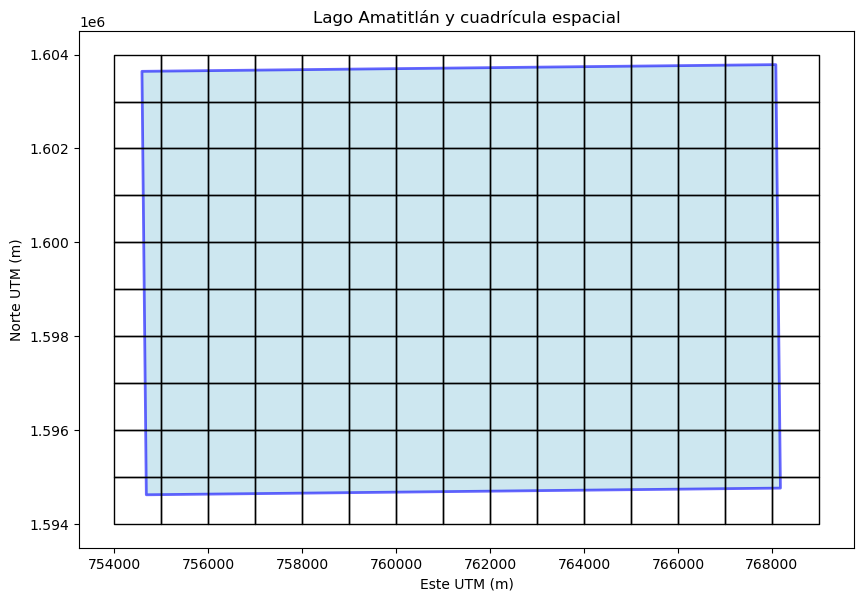

In [89]:
fig, ax = plt.subplots(figsize=(10, 10))

amatitlan_utm.plot(
    ax=ax,
    facecolor="lightblue",
    edgecolor="blue",
    linewidth=2,
    alpha=0.6
)

bloques_amatitlan.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1
)

ax.set_aspect("equal")

ax.set_title(
    "Lago Amatitlán y cuadrícula espacial"
)

ax.set_xlabel("Este UTM (m)")
ax.set_ylabel("Norte UTM (m)")

plt.show()

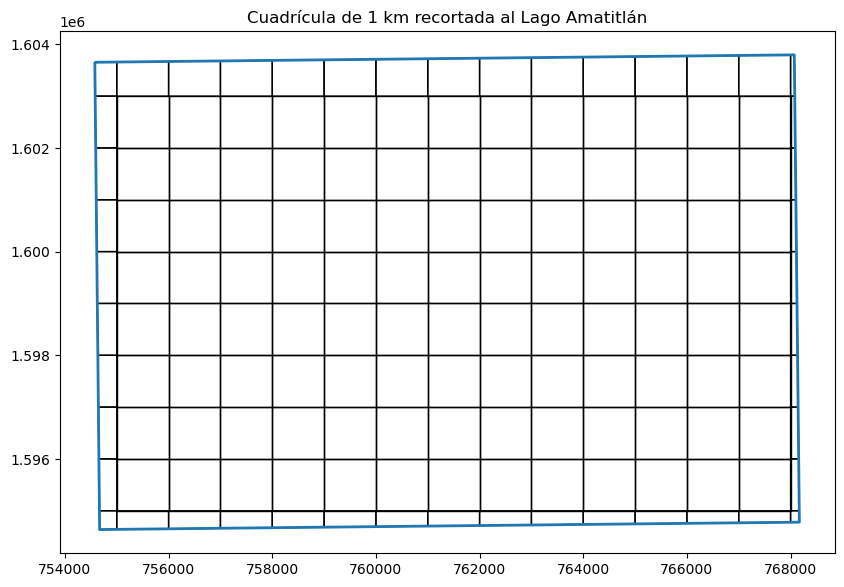

In [90]:
bloques_recortados = gpd.overlay(
    bloques_amatitlan,
    amatitlan_utm,
    how="intersection"
)

fig, ax = plt.subplots(figsize=(10, 10))

bloques_recortados.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1
)

amatitlan_utm.boundary.plot(
    ax=ax,
    linewidth=2
)

ax.set_aspect("equal")

plt.title(
    "Cuadrícula de 1 km recortada al Lago Amatitlán"
)

plt.show()

['amatitlan' 'atitlan']


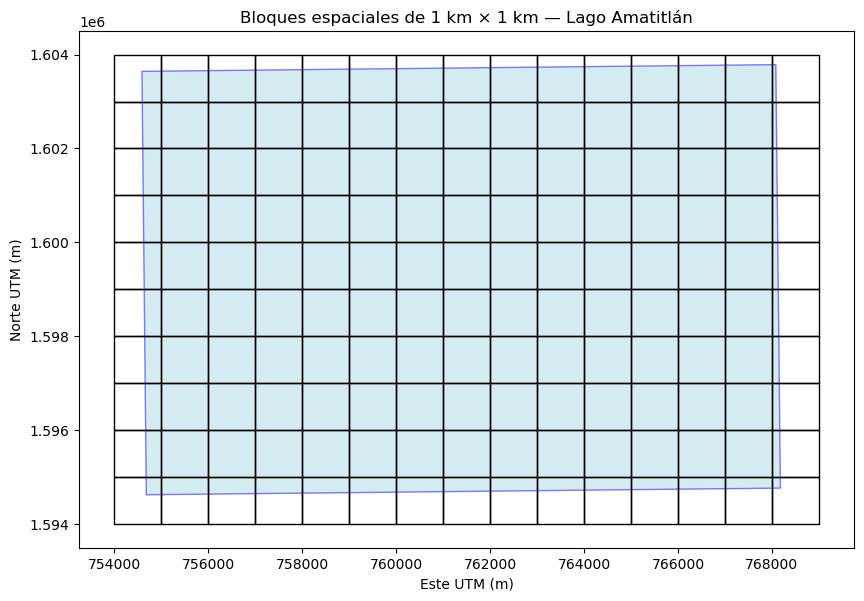

In [75]:
#MAPA DE AMATITLAN
bloques_amatitlan = gdf_bloques[gdf_bloques["lago"] == "amatitlan"]
print(df_respuesta["lago"].unique())
fig, ax = plt.subplots(figsize=(10, 10))

# Contorno del lago
amatitlan_utm.plot(
    ax=ax,
    facecolor="lightblue",
    edgecolor="blue",
    alpha=0.5
)

# Cuadrícula
bloques_amatitlan.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1
)

ax.set_title(
    "Bloques espaciales de 1 km × 1 km — Lago Amatitlán"
)

ax.set_xlabel("Este UTM (m)")
ax.set_ylabel("Norte UTM (m)")

ax.set_aspect("equal")

plt.show()

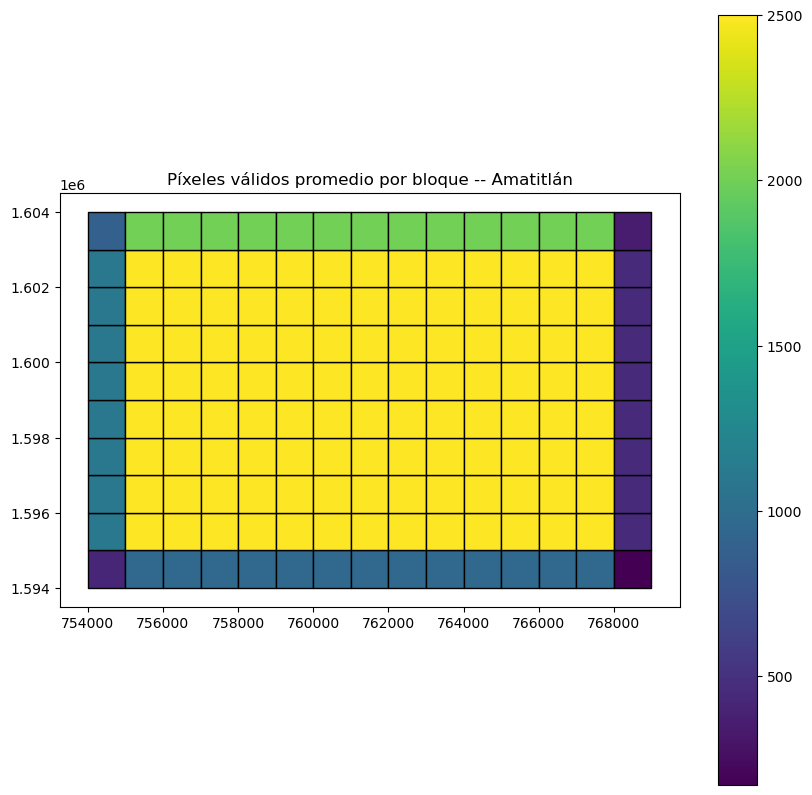

In [94]:
pixeles_bloque = (
    df_respuesta
    .groupby([
        "lago",
        "bloque_fila",
        "bloque_columna"
    ])["pixeles_validos"]
    .mean()
    .reset_index(
        name="pixeles_validos_promedio"
    )
)

gdf_bloques_pixeles = gdf_bloques.merge(
    pixeles_bloque,
    on=[
        "lago",
        "bloque_fila",
        "bloque_columna"
    ]
)

gdf_bloques_pixeles[
    gdf_bloques_pixeles["lago"] == "amatitlan"
].plot(
    column="pixeles_validos_promedio",
    legend=True,
    edgecolor="black",
    figsize=(10, 10)
)

plt.title(
    "Píxeles válidos promedio por bloque -- Amatitlán"
)

plt.show()

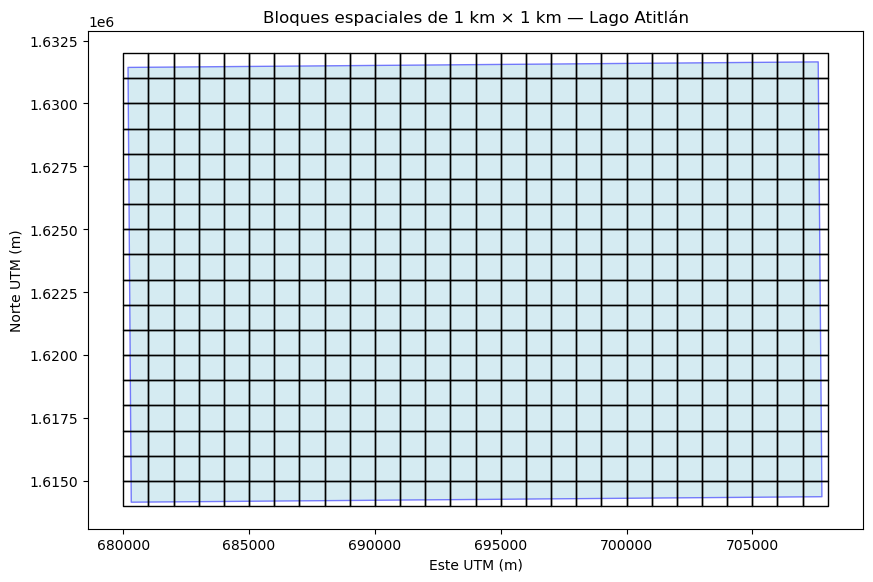

In [76]:
#Lago de atitlan
bloques_atitlan = gdf_bloques[
    gdf_bloques["lago"] == "atitlan"
]

fig, ax = plt.subplots(figsize=(10, 10))

atitlan_utm.plot(
    ax=ax,
    facecolor="lightblue",
    edgecolor="blue",
    alpha=0.5
)

bloques_atitlan.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1
)

ax.set_title(
    "Bloques espaciales de 1 km × 1 km — Lago Atitlán"
)

ax.set_xlabel("Este UTM (m)")
ax.set_ylabel("Norte UTM (m)")

ax.set_aspect("equal")

plt.show()

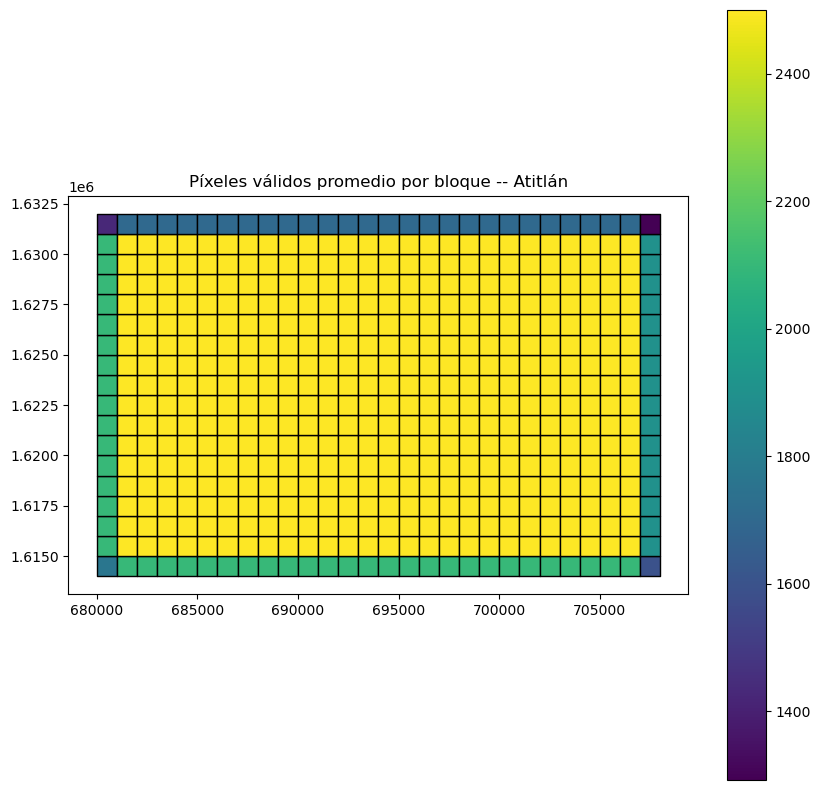

In [93]:
pixeles_bloque = (
    df_respuesta
    .groupby([
        "lago",
        "bloque_fila",
        "bloque_columna"
    ])["pixeles_validos"]
    .mean()
    .reset_index(
        name="pixeles_validos_promedio"
    )
)

gdf_bloques_pixeles = gdf_bloques.merge(
    pixeles_bloque,
    on=[
        "lago",
        "bloque_fila",
        "bloque_columna"
    ]
)

gdf_bloques_pixeles[
    gdf_bloques_pixeles["lago"] == "atitlan"
].plot(
    column="pixeles_validos_promedio",
    legend=True,
    edgecolor="black",
    figsize=(10, 10)
)

plt.title(
    "Píxeles válidos promedio por bloque -- Atitlán"
)

plt.show()